In [38]:
import librosa
import librosa.display
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import normalize

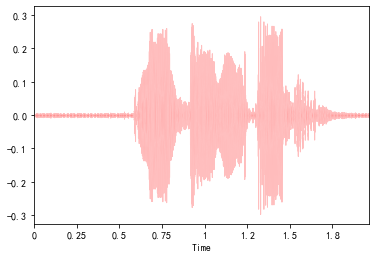

In [39]:
test_vedio, sr = librosa.load('19-198-0000.flac')
librosa.display.waveplot(test_vedio, sr=sr, max_sr=1000, alpha=0.25, color='r')

In [40]:
S = librosa.feature.melspectrogram(y=test_vedio, sr=sr)
print(S.shape)
S

(128, 85)


array([[6.37732670e-02, 8.71560127e-02, 9.45213288e-02, ...,
        9.59080383e-02, 9.48623791e-02, 9.92535427e-02],
       [2.31471173e-02, 1.44104250e-02, 1.31725650e-02, ...,
        1.39228310e-02, 1.29877953e-02, 9.38136131e-03],
       [7.29109044e-04, 2.42999871e-03, 3.16365855e-03, ...,
        2.07256828e-03, 8.03368574e-04, 4.02875274e-04],
       ...,
       [6.09892368e-08, 1.52472683e-08, 2.26433347e-17, ...,
        1.24119774e-17, 6.78337253e-09, 5.77939431e-07],
       [5.99012822e-08, 1.49752815e-08, 3.34028336e-17, ...,
        1.83953950e-17, 6.65619782e-09, 5.67103598e-07],
       [5.92027938e-08, 1.48006585e-08, 2.81088413e-17, ...,
        2.23056068e-17, 6.57606236e-09, 5.60275566e-07]], dtype=float32)

In [41]:
print(sr)
#一个提取特征的例子
#S = librosa.feature.melspectrogram(y=test_vedio, sr=sr, n_mels=64, hop_length=sr * 16 / 1000, win_length=sr * 32 / 1000)
S = librosa.feature.melspectrogram(y=test_vedio, sr=sr, n_mels=64, hop_length=int(sr*16/1000), win_length=int(sr*32/1000))
print(S.shape)
N, D = S.shape
print(N, D)
#随机提取其中的一秒（64帧）
rand = random.randint(64, D-1)
S = S[:, rand-64: rand]
print(S.shape)
S

22050
(64, 124)
64 124
(64, 64)


array([[1.11125335e-02, 1.27812643e-02, 1.09241158e-02, ...,
        8.71554762e-03, 1.22708995e-02, 8.94903392e-03],
       [1.27611775e-03, 1.77804765e-03, 1.58198574e-03, ...,
        1.42053263e-02, 2.46604276e-03, 2.22081831e-03],
       [5.62805915e-04, 1.49639789e-03, 8.49715550e-04, ...,
        3.01785413e-02, 2.62091891e-03, 1.37879164e-03],
       ...,
       [1.56713999e-17, 3.86677985e-17, 3.92456206e-17, ...,
        6.34268605e-15, 9.79661578e-16, 7.80661629e-17],
       [1.09382046e-17, 1.74722846e-17, 1.04258672e-17, ...,
        3.50549646e-15, 6.83600375e-16, 9.58482101e-17],
       [9.10478279e-18, 1.38335353e-17, 8.77749141e-18, ...,
        3.14311946e-15, 4.71668285e-16, 8.35032873e-17]], dtype=float32)

In [42]:
S_next = normalize(S, axis=1, norm='max')
#np.set_printoptions(threshold=np.inf)
S_next

array([[5.22000432e-01, 6.00387394e-01, 5.13149679e-01, ...,
        4.09404337e-01, 5.76413512e-01, 4.20372128e-01],
       [8.98337513e-02, 1.25167668e-01, 1.11365676e-01, ...,
        1.00000000e+00, 1.73599869e-01, 1.56337008e-01],
       [7.44166027e-04, 1.97860133e-03, 1.12353021e-03, ...,
        3.99033576e-02, 3.46549088e-03, 1.82309723e-03],
       ...,
       [1.56713999e-17, 3.86677985e-17, 3.92456206e-17, ...,
        6.34268605e-15, 9.79661578e-16, 7.80661629e-17],
       [1.09382046e-17, 1.74722846e-17, 1.04258672e-17, ...,
        3.50549646e-15, 6.83600375e-16, 9.58482101e-17],
       [9.10478279e-18, 1.38335353e-17, 8.77749141e-18, ...,
        3.14311946e-15, 4.71668285e-16, 8.35032873e-17]], dtype=float32)

In [43]:
def extract_features(file_name):
    vedio, sr = librosa.load(file_name)
    Spec = librosa.feature.melspectrogram(y=vedio, sr=sr, n_mels=64, hop_length=int(sr*16/1000), win_length=int(sr*32/1000))
    N, D = Spec.shape
    rand = random.randint(64, D-1)
    Spec = Spec[:, rand-64: rand]
    result = normalize(Spec, axis=1, norm='max')
    return result

  0%|          | 0/251 [00:00<?, ?it/s]

E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0000.flac
1
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0001.flac
2
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0002.flac
3
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0003.flac
4
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0004.flac
5
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0005.flac
6
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0006.flac
7
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0007.flac
8
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0008.flac
9
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0009.flac
10
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0010.flac
11
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0011.flac
12
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0012.flac
13
E:\project\LibriSpeech\train-clean-100\103\1240\103-1240-0013.flac
14
E:\project\LibriSpeech\train-

  0%|          | 1/251 [00:27<1:56:16, 27.90s/it]

101
E:\project\LibriSpeech\train-clean-100\103\1241\103-1241-0043.flac
102
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0000.flac
103
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0001.flac
104
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0002.flac
105
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0003.flac
106
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0004.flac
107
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0005.flac
108
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0006.flac
109
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0007.flac
110
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0008.flac
111
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0009.flac
112
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0010.flac
113
E:\project\LibriSpeech\train-clean-100\1034\121119\1034-121119-0011.flac
114
E

  1%|          | 2/251 [00:47<1:35:40, 23.06s/it]

...

26160
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0009.flac
26161
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0010.flac
26162
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0011.flac
26163
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0012.flac
26164
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0013.flac
26165
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0014.flac
26166
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0015.flac
26167
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0016.flac
26168
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0017.flac
26169
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0018.flac
26170
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0019.flac
26171
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0020.flac
26172
E:\project\LibriSpeech\train-clean-100\831\130746\831-130746-0021.flac

 96%|█████████▋| 242/251 [04:04<00:00, 42.84it/s]


E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0008.flac
27089
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0009.flac
27090
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0010.flac
27091
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0011.flac
27092
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0012.flac
27093
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0013.flac
27094
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0014.flac
27095
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0015.flac
27096
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0016.flac
27097
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0017.flac
27098
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0018.flac
27099
E:\project\LibriSpeech\train-clean-100\8609\262281\8609-262281-0019.flac
27100
E:\project\LibriSpeech\train-clean-100\8609\262281\

100%|██████████| 251/251 [04:04<00:00,  1.03it/s]


27947
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0038.flac
27948
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0039.flac
27949
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0040.flac
27950
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0041.flac
27951
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0042.flac
27952
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0043.flac
27953
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0044.flac
27954
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0045.flac
27955
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0046.flac
27956
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0047.flac
27957
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0048.flac
27958
E:\project\LibriSpeech\train-clean-100\8838\298546\8838-298546-0049.flac
27959
E:\project\LibriSpeech\train-clean-100\8838\2

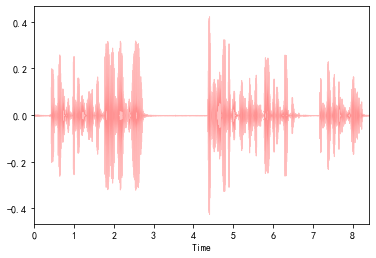

In [44]:
from tqdm import tqdm
cnt=0
pre = np.zeros((1000, 64, 64), dtype=float)
src_path = 'E:\project\LibriSpeech\\train-clean-100\\'
for speaker in tqdm(os.listdir(src_path)):
    if os.path.isdir(src_path + speaker):
        for sub_level in os.listdir(src_path + speaker):
            if os.path.isdir(src_path + speaker + '/' +sub_level):
                for file in os.listdir(src_path + speaker + '/' +sub_level):
                    if file.endswith('.flac'):
                        s = src_path + speaker + '\\' +sub_level + '\\' + file
                        print(s)
                        if cnt < 1000:
                            pre[cnt, :, :] = extract_features(s)
                            #print(pre[cnt, :, :])
                        cnt+=1
                        print(cnt)
np.save(file="data.npy", arr=pre)
test_vedio, sr = librosa.load(s)
librosa.display.waveplot(test_vedio, sr=sr, max_sr=1000, alpha=0.25, color='r')

In [45]:
b = np.load(file="data.npy")
b

array([[[7.70628035e-01, 6.83110237e-01, 7.25110352e-01, ...,
         5.71746230e-01, 7.40599275e-01, 6.33878767e-01],
        [6.18346095e-01, 6.15769148e-01, 6.00941896e-01, ...,
         4.92338330e-01, 6.24386847e-01, 4.95460600e-01],
        [5.75420022e-01, 5.95760822e-01, 6.21585548e-01, ...,
         3.47592950e-01, 2.95008361e-01, 3.64069015e-01],
        ...,
        [6.40332810e-15, 1.22915640e-15, 1.86864658e-15, ...,
         1.15062417e-15, 2.03538629e-15, 8.14033126e-16],
        [5.19683512e-15, 1.12232056e-15, 1.62884266e-15, ...,
         9.88626045e-16, 1.64881189e-15, 5.46526516e-16],
        [3.06859539e-15, 1.14112734e-15, 1.52768544e-15, ...,
         8.81019085e-16, 1.35313206e-15, 7.61649220e-16]],

       [[7.77373016e-01, 6.53334558e-01, 1.00000000e+00, ...,
         6.57818735e-01, 6.69883370e-01, 5.74893653e-01],
        [8.68926704e-01, 6.51431262e-01, 1.00000000e+00, ...,
         6.39566243e-01, 5.90376377e-01, 6.10062838e-01],
        [5.19237936e-01, 